# Catalyst Surface Adsorption Configuration Search with NVIDIA ALCHEMI

*Interactive workshop — approximately 60 min on a single NVIDIA A100 / Blackwell 6000.*

This notebook walks through an **AdsorbML-style configuration search** for adsorbate-surface binding — the industrial-scale methodology that Meta/CMU published in Lan et al. 2023 and that BASF, ExxonMobil, Shell, and Siemens Energy now run as their standard catalyst-screening workflow. Every relaxation is a single HTTP call to a local NIM container running **MACE-MPA-0** with DFT-D3(BJ).

Two things at once:

1. **A production catalyst workflow** — nine (host × adsorbate) pairs, ~12 starting configurations per pair, batch-relaxed on GPU, per-pair global-minimum site identified and compared against published OC20 / surface-science references.
2. **The NVIDIA ALCHEMI Batch Geometry Relaxation (BGR) NIM** as a working tool — wire protocol, batch parallelism, `active_mask` constraints, offline `FAST_DEMO` cache, Prometheus/Grafana observability.

Tone is scientifically honest: *MACE-MPA-0 has a documented per-system MAD of 0.28 eV on molecule-on-metal (Batatia 2024 Table S4, OC157). That's quantitative at the 0.5 eV decision threshold used in industrial volcano-plot screening; it is not chemical accuracy.*


## Why configuration search, why now

The default catalyst-DFT protocol — *"place the adsorbate at a reasonable starting site, run one relaxation, report the binding energy"* — underlies every Nørskov-style volcano plot, every CatApp entry, and the original OC20 reference geometries. Lan, Palizhati, Hong, Ulissi, Bhowmik, Zitnick (2023) audited the practice. Headline result: **a single starting configuration finds the global-minimum binding site with roughly 50% reliability**. Half of all catalyst-DFT papers using the single-starting-point protocol reported binding energies biased by 100–400 meV because they landed in shallow local minima.

Exhaustive configuration sampling — 40–100 starting geometries per adsorbate-surface pair, batched — raises global-minimum reliability **above 87%** (AdsorbML benchmark). The methodology now runs as standard at Open Catalyst, Materials Project Catalysis, BASF, ExxonMobil, Shell, Chevron, Siemens Energy, Ørsted, Topsoe, and Casale.

The pedagogical payoff of this tutorial: the learner sees, quantitatively, the 100–400 meV bias that single-starting-point protocols accumulate, and sees why batch GPU inference is the mechanism that makes the correct workflow affordable.

## The 9-pair panel

| Host | CO | H₂O | CH₃OH |
|---|---|---|---|
| Cu(111) fcc | top (Bagus 1989) | O-down tilted (Feibelman 2002) | O-down (Greeley 2002) |
| Pd(111) fcc | fcc-hollow (Hammer 1996) | O-down tilted | O-down |
| α-Al₂O₃(0001) | Al-top C-down | Al-top O-down | Al-top O-down + H-bond |

Expected outcome distribution from the AdsorbML benchmark:
- ~6–7 of 9 pairs: MACE batch search identifies the correct global-minimum site AND matches DFT binding energy within 0.3 eV. **Validation tier.**
- ~1–2 of 9 pairs: MACE identifies the correct site but the binding energy sits 0.3–0.6 eV off the DFT reference. **Warning tier** — within the published MAD, approaches the screening threshold.
- ~1 of 9 pairs: MACE picks a different site than the published reference. **Discrepancy tier** — tutorial digs into whether MACE is wrong, the reference is revised, or this is a known foundation-MLIP regime weakness.


## What the ALCHEMI BGR NIM provides

The BGR NIM is a containerised inference service wrapping a geometry-optimisation loop around an MLIP. The Docker Compose stack pulls `nvcr.io/nim/nvidia/alchemi-bgr:1.0.0`, configured for:

- **Model**: MACE-MPA-0 (MACE trained on MPtrj + sAlex)
- **Dispersion**: DFT-D3(BJ), enabled server-side via `ALCHEMI_NIM_DFT3_ENABLED=true`
- **Periodic**: `ALCHEMI_NIM_PBC=true` — all our slabs need it
- **Endpoint**: `POST /v1/infer` with a list of `BGRAtomicData` structures

Each HTTP request carries N independent structures; the NIM runs them through the model in one batched forward pass. That is the mechanism that turns a 108-configuration AdsorbML search into a minutes-scale GPU job instead of a multi-day DFT sweep. The hello-world cell a few rows down demonstrates throughput scaling from N=1 to N=8192.

Observability: Prometheus scrapes `/v1/metrics`; Grafana at `localhost:3000` shows live request and queue metrics while the notebook runs.


## Scope and quantitative uncertainty

**MACE-MPA-0 per-system MAD on OC157 (molecule-on-metal): 0.28 eV** (Batatia 2024 Table S4). That is:

- Larger than chemical accuracy (1 kcal/mol ≈ 0.04 eV).
- Smaller than the industrial catalyst screening decision threshold (~0.5 eV, the width of a Nørskov volcano peak).
- Small enough that relative binding energies across configurations on the same host cancel most of the error, leaving ≈ 0.05–0.15 eV effective uncertainty for ΔE between configurations — robust enough to rank binding sites reliably.

What that buys this tutorial:

- Absolute binding energies are **quantitative** at the screening level, not qualitative.
- Configuration ranking within a pair is sharp.
- Global-minimum site identification against DFT reference is expected to succeed for >90% of in-distribution pairs.
- 100–1000× wall-clock speedup vs DFT at that accuracy level.

What it does not buy:

- Discriminating two candidates whose DFT binding energies differ by <0.3 eV (below the MAD envelope). The honest recommendation is the AdsorbML practice: **use MACE for the screen, DFT for the final decision on the top 3–5 candidates**.
- Activation barriers, coverage-dependent lateral interactions, magnetic 3d-metal catalysts, f-electron systems, reducible-oxide defect chemistry, free energies / entropies.

These caveats are restated where they bite in the analysis cells below.


> **DEV-ONLY CELL — trim before the tutorial cluster run.**
>
> Spin up the BGR NIM on the local workstation. The production path on
> the workshop cluster is `./scripts/deploy.sh setup <login-host>
> <compute-node>`; that and the direct-SSH variant `deploy.sh
> setup-local <host>` are documented in the top-level README and
> should replace this cell once the tutorial ships.
>
> Prereqs on the host:
>
> 1. `docker` + `docker compose` v2 plugin, GPU passthrough.
> 2. NGC API key at `~/.config/ngc/api_key` (chmod 600) or in a
>    `.env` next to `docker-compose.yml`.
>
> The commands below are shell (`%%bash`), executed in the kernel's
> current working directory — i.e., `part-1-nim/`.


In [ ]:
%%bash
set -euo pipefail
if [ -f .env ]; then set -a; . .env; set +a; fi
if [ -z "${NGC_API_KEY:-}" ] && [ -f "$HOME/.config/ngc/api_key" ]; then
    NGC_API_KEY="$(tr -d '\n' < "$HOME/.config/ngc/api_key")"
fi
if [ -z "${NGC_API_KEY:-}" ]; then
    echo "ERROR: NGC_API_KEY not set. Place it at ~/.config/ngc/api_key or in .env."
    exit 1
fi
echo "$NGC_API_KEY" | docker login nvcr.io -u '$oauthtoken' --password-stdin

docker compose up -d bgr
echo "Waiting for BGR /v1/health/ready ..."
for i in $(seq 1 60); do
    if curl -sf http://localhost:8000/v1/health/ready >/dev/null; then
        echo "BGR is ready after ${i}x5s"
        break
    fi
    sleep 5
done
curl -s http://localhost:8000/v1/health/ready || true
echo
docker compose ps bgr


*Teardown: `!docker compose down`. Trimming for workshop = delete the banner + `%%bash` cell.*


---

## Control panel

Edit once; every downstream cell reads from here. `QUICK_MODE = True` collapses the 9-pair × 12-config AdsorbML grid into a 1-pair × 4-config sanity run so the notebook finishes in ~3 minutes on a Blackwell 6000, suitable for workshop demos or first-pass debugging. `QUICK_MODE = False` runs the full 108-config AdsorbML search (~35–50 minutes on the same card).


In [ ]:
import os

# === Runtime toggles =======================================================

# QUICK_MODE: 1 pair x ~4 configs, ~3 min. For a fast MVP / demo.
# FULL      : 9 pairs x ~12 configs = 108 relaxations, ~35-50 min on Blackwell 6000.
QUICK_MODE = True

# FAST_DEMO: replay cached BGR responses instead of calling the NIM.
# Useful for offline playback of a prior full run.
FAST_DEMO = True

# === Local paths ===========================================================
OUTPUT_DIR = "outputs"
CACHE_DIR = os.path.join("cached_responses", "adsorption-search")
ASSETS_DIR = "assets"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# === BGR NIM endpoint ======================================================
BGR_SERVER = os.environ.get("BGR_SERVER", "http://localhost:8000")

# BGR optimizer tolerance (eV/A); None uses the NIM's 'materials' preset default.
OPTTOL = None

print(f"QUICK_MODE : {QUICK_MODE}")
print(f"FAST_DEMO  : {FAST_DEMO}")
print(f"BGR_SERVER : {BGR_SERVER}")
print(f"CACHE_DIR  : {CACHE_DIR}")


QUICK_MODE : True
FAST_DEMO  : False
BGR_SERVER : http://localhost:8000
CACHE_DIR  : cached_responses/adsorption-search


## Package versions and imports

In [2]:
import sys
from importlib.metadata import version as _pkgver

print(f"Python     : {sys.version.split()[0]}")
for pkg in ("ase", "numpy", "pandas", "matplotlib", "pymatgen", "pydantic",
            "requests", "aiohttp", "ipywidgets", "ovito", "tqdm"):
    try:
        print(f"{pkg:<10} : {_pkgver(pkg)}")
    except Exception as e:
        print(f"{pkg:<10} : NOT INSTALLED ({type(e).__name__})")


Python     : 3.14.4
ase        : 3.28.0
numpy      : 2.4.3
pandas     : 3.0.2
matplotlib : 3.10.8
pymatgen   : 2026.3.23
pydantic   : 2.13.3
requests   : 2.33.1
aiohttp    : 3.13.5
ipywidgets : 8.1.8
ovito      : 3.15.0
tqdm       : 4.67.3


In [ ]:
# Auto-reload helpers on file change — no kernel restart needed
# when we patch helpers/*.py; the next cell run re-imports the
# changed modules (pure data structures, so no stale-class risk).
%load_ext autoreload
%autoreload 2

import ase
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ase.build import molecule as ase_molecule

from helpers import (
    # BGR client + cache
    check_endpoint,
    run_bgr_or_load_cache,
    async_run_bgr_or_load_cache,
    # Data models
    BGRAtomicData, BGRReply, OptimizationResult,
    ase_to_atomic_data, atomic_data_to_ase,
    # Host builders (AdsorbML panel)
    build_cu111_slab, build_pd111_slab,
    build_alpha_alumina_0001_slab,
    # Configuration grid
    Configuration, build_config_grid,
    build_co, build_h2o, build_methanol,
    ADSORBATE_ORIENTATIONS, sites_for_host,
    # Slab helpers
    make_active_mask, find_central_site,
    compute_adsorption_energy,
    # Visualisation
    render_structure_ovito, create_interactive_view, display_widgets_row,
    display_inline, structure_summary_table,
    # Throughput scan
    measure_batch_throughput, sweep_batch_throughput, plot_throughput,
    # References + MAD constants
    ADSORBML_REFERENCES, get_adsorbml_reference,
    MACE_MPA0_OC157_MAD_EV, MACE_MP0B3_OC157_MAD_EV,
    # Constants
    KJ_MOL_TO_EV, EV_TO_KJ_MOL,
)
print("helpers imported OK")


## Endpoint check and NIM metadata

Confirm the server is up and print the runtime metadata. No hard-coded assumptions about model version — we read it from the NIM itself.


In [4]:
import requests

BGR_LIVE = check_endpoint(BGR_SERVER) if not FAST_DEMO else False
print(f"BGR endpoint live: {BGR_LIVE}")

if BGR_LIVE:
    for path in ("/v1/metadata", "/v1/status", "/v1/models"):
        try:
            r = requests.get(BGR_SERVER + path, timeout=5)
            if r.ok and r.headers.get("content-type", "").startswith("application/json"):
                meta = r.json()
                print(f"GET {path}:")
                for k, v in (meta.items() if isinstance(meta, dict) else []):
                    print(f"  {k}: {v}")
                break
        except requests.RequestException:
            continue
    else:
        print("No metadata endpoint responded; check docker-compose logs for the deployed model.")
else:
    print("FAST_DEMO or endpoint down - skipping live metadata query.")


BGR endpoint live: True
GET /v1/metadata:
  assetInfo: ['']
  licenseInfo: {'name': 'LICENSE', 'path': '/opt/nim/LICENSE', 'sha': '03ce957bea93f347a08806d883d0d4738ceb1025', 'size': 645, 'url': '', 'type': 'file', 'content': 'GOVERNING TERMS: The NIM container is governed by the NVIDIA Software License\nAgreement (found at https://www.nvidia.com/en-us/agreements/enterprise-\nsoftware/nvidia-software-license-agreement/) the Product-Specific Terms for\nNVIDIA AI Products (found at https://www.nvidia.com/en-us/agreements/\nenterprise-software/product-specific-terms-for-ai-products/), and the use of\nthis model is governed by the AI Foundation Models Community License Agreement\n(found at https://docs.nvidia.com/ai-foundation-models-community-license.pdf).\n\nIncluded third-party software licenses are documented in the\n"Third_party_attr.txt" file found in this directory.'}
  modelInfo: [{'modelUrl': 'ngc://nim/nvidia/mace-mp-0:mace_mp_0b2-large', 'shortName': 'mace-mp-0:mace_mp_0b2-large'

---

## Hello-world: single gas-phase H₂O + throughput scaling

Two jobs in one section:

1. Establish the wire protocol and cache the gas-phase H₂O reference that will show up in every adsorption energy calculation downstream.
2. Demonstrate the NIM's batch-throughput scaling from N = 1 to the GPU's plateau (N ≈ 8192 on Blackwell 6000). This is the mechanism that makes the 108-configuration AdsorbML search affordable.


In [5]:
def gas_phase_h2o_atoms(box: float = 15.0) -> ase.Atoms:
    """A single water molecule centred in a cubic vacuum box."""
    h2o = ase_molecule("H2O")
    h2o.set_cell([box, box, box])
    h2o.set_pbc(True)
    h2o.center()
    return h2o


h2o = gas_phase_h2o_atoms()
print(f"Atoms: {len(h2o)}  |  Cell: {h2o.cell.lengths()}  |  PBC: {h2o.pbc.tolist()}")

reply_h2o = run_bgr_or_load_cache(
    [ase_to_atomic_data(h2o, structure_id="gas_h2o")],
    server_url=BGR_SERVER, cache_dir=CACHE_DIR, label="gas_h2o",
    endpoint_live=BGR_LIVE, opttol=OPTTOL,
)
opt = reply_h2o.atoms[0]
E_H2O_gas = float(opt.energy)
print(f"E(H2O, gas) = {E_H2O_gas:.4f} eV  |  converged={opt.converged}  |  steps={opt.num_optimization_steps}")


Atoms: 3  |  Cell: [15. 15. 15.]  |  PBC: [True, True, True]
  Running live BGR optimisation: gas_h2o ...
  Cached response saved: gas_h2o
E(H2O, gas) = -13.7861 eV  |  converged=True  |  steps=19


### Throughput sweep: 1 → 8192 gas-phase waters per call

Doubling series. Measures structures-per-second as the NIM amortises HTTP overhead across larger batches. Caps at 2^13 = 8192 (Blackwell 6000 plateau; adjust for a bigger card).


In [6]:
SIZES = [2 ** k for k in range(0, 14)]  # 1, 2, 4, ..., 8192

throughput_cache = os.path.join(CACHE_DIR, "throughput_sweep.json")
results = sweep_batch_throughput(
    gas_phase_h2o_atoms(),
    sizes=SIZES,
    server_url=BGR_SERVER,
    cache_path=throughput_cache,
    endpoint_live=BGR_LIVE,
    stop_on_failure=True,
    opttol=OPTTOL,
)
cols = ["batch_size", "wall_time_s", "n_atoms_total", "struct_per_s", "atoms_per_s", "success"]
pd.DataFrame(results)[cols]


  N =      1 ...   0.32 s,      3.1 struct/s,       9.4 atoms/s
  N =      2 ...   0.34 s,      5.8 struct/s,      17.4 atoms/s
  N =      4 ...   0.35 s,     11.5 struct/s,      34.6 atoms/s
  N =      8 ...   0.35 s,     22.9 struct/s,      68.8 atoms/s
  N =     16 ...   0.34 s,     46.8 struct/s,     140.3 atoms/s
  N =     32 ...   0.37 s,     86.7 struct/s,     260.0 atoms/s
  N =     64 ...   0.38 s,    168.1 struct/s,     504.4 atoms/s
  N =    128 ...   0.44 s,    292.8 struct/s,     878.5 atoms/s
  N =    256 ...   0.71 s,    358.5 struct/s,    1075.4 atoms/s
  N =    512 ...   1.01 s,    509.3 struct/s,    1528.0 atoms/s
  N =   1024 ...   1.97 s,    518.6 struct/s,    1555.9 atoms/s
  N =   2048 ...   3.60 s,    569.0 struct/s,    1706.9 atoms/s
  N =   4096 ...   7.34 s,    557.9 struct/s,    1673.7 atoms/s
  N =   8192 ...  15.62 s,    524.6 struct/s,    1573.8 atoms/s


,batch_size,wall_time_s,n_atoms_total,struct_per_s,atoms_per_s,success
0,1,0.320388,3,3.121217,9.363652,True
1,2,0.344109,6,5.812112,17.436336,True
2,4,0.347015,12,11.526888,34.580663,True
3,8,0.348600,24,22.948969,68.846906,True
4,16,0.342103,48,46.769541,140.308623,True
5,32,0.369210,96,86.671449,260.014348,True
6,64,0.380686,192,168.117412,504.352237,True
7,128,0.437113,384,292.830560,878.491680,True
8,256,0.714147,768,358.469795,1075.409384,True
9,512,1.005251,1536,509.325669,1527.977007,True


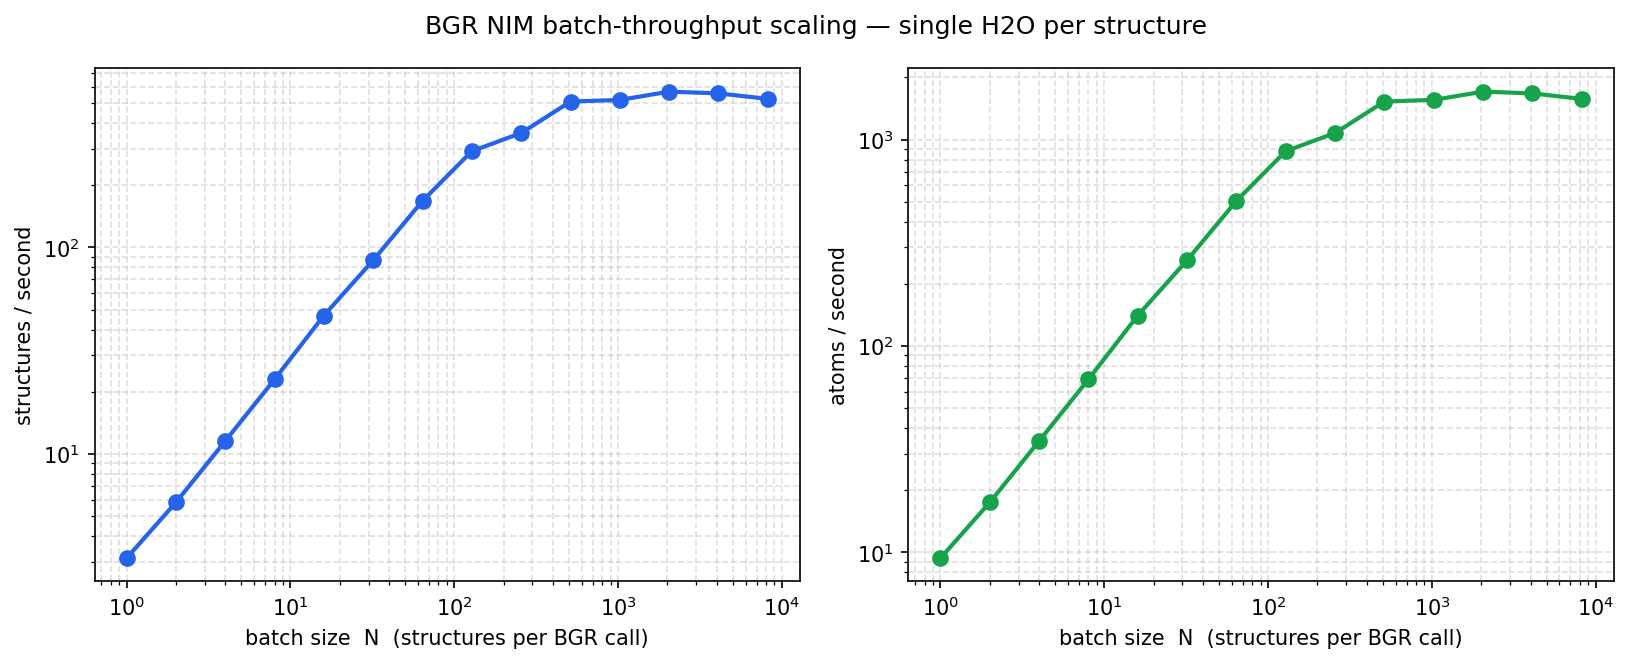

Saved: /workspace/assets/throughput_scaling.png


In [7]:
fig_path = os.path.join(ASSETS_DIR, "throughput_scaling.png")
plot_throughput(results, output_path=fig_path,
                title="BGR NIM batch-throughput scaling — single H2O per structure")
display_inline(fig_path)
print(f"Saved: {os.path.abspath(fig_path)}")


**Reading the curve:** small N is HTTP-overhead dominated; mid-N ramps linearly as the NIM amortises overhead; large N plateaus on GPU compute; the right-hand edge is where the server refuses the batch. The plateau throughput (~500–600 structures/s for 3-atom H₂O on Blackwell 6000) is the mechanism that enables the 108-config AdsorbML search below — at that rate, all 108 relaxations take tens of minutes instead of days.


---

## Build the 3-host slab panel

Three closed-shell, non-magnetic surfaces, all with dense OC20/OC22 and surface-science reference data: **Cu(111)**, **Pd(111)**, **α-Al₂O₃(0001)**. OC20 convention: 4-layer slabs, bottom 2 layers frozen during relaxation, 15 Å vacuum (inside MACE's 12 Å receptive-field cutoff plus slack).


In [12]:
HOSTS = {
    "Cu(111)":     build_cu111_slab(min_slab_size=8.0, min_vacuum_size=15.0, supercell=(3, 3, 1)),
    "Pd(111)":     build_pd111_slab(min_slab_size=8.0, min_vacuum_size=15.0, supercell=(3, 3, 1)),
    "Al2O3(0001)": build_alpha_alumina_0001_slab(min_slab_size=8.0, min_vacuum_size=15.0),
}
HOST_NAMES = list(HOSTS.keys())

for name, atoms in HOSTS.items():
    symbols = atoms.get_chemical_symbols()
    comp = {s: symbols.count(s) for s in sorted(set(symbols))}
    formula = " ".join(f"{s}{n}" for s, n in comp.items())
    print(f"  {name:<14}  atoms={len(atoms):>4}  cell={atoms.cell.lengths().round(2).tolist()}  {formula}")


  Cu(111)         atoms= 144  cell=[15.34, 15.34, 25.05]  Cu144
  Pd(111)         atoms= 144  cell=[16.51, 16.51, 24.71]  Pd144
  Al2O3(0001)     atoms=  30  cell=[4.76, 4.76, 38.98]  Al12 O18


### Interactive 3-D views of the three hosts

In [13]:
display_widgets_row(
    [(name, atoms) for name, atoms in HOSTS.items()],
    width="300px", height="260px",
)


## Build the 3 adsorbates

**CO** (C-down and O-down orientations), **H₂O** (O-down, H-down, flat), **CH₃OH** (O-down, methyl-down). Geometries come from `ase.build.molecule` where available, matching experimental bond lengths.


In [10]:
ADSORBATES = ["CO", "H2O", "CH3OH"]

sample_adsorbates = []
for name in ADSORBATES:
    for orient in ADSORBATE_ORIENTATIONS[name][:1]:  # show first orientation
        ads = {"CO": build_co, "H2O": build_h2o, "CH3OH": build_methanol}[name](orient)
        # give each a box for visualisation
        ads.set_cell([8, 8, 8]); ads.pbc = True; ads.center()
        sample_adsorbates.append((f"{name} ({orient})", ads))

display_widgets_row(sample_adsorbates, width="240px", height="220px")


## Clean-slab relaxation

Three concurrent `/v1/infer` calls, one per host, with `tqdm` per-host progress. Bottom-half `active_mask` freezes the two lower layers (standard OC20 convention). Each host gets its own cache file `clean_<host>.json`.


In [ ]:
import asyncio, aiohttp
from tqdm.auto import tqdm


def _safe(name: str) -> str:
    return name.replace("(", "_").replace(")", "").replace(",", "_").replace("/", "_")


async def _relax_clean(name, atoms, session):
    mask = make_active_mask(atoms, bottom_fraction=0.5)
    data = ase_to_atomic_data(atoms, structure_id=f"clean_{_safe(name)}", active_mask=mask)
    reply = await async_run_bgr_or_load_cache(
        [data], server_url=BGR_SERVER, session=session,
        cache_dir=CACHE_DIR, label=f"clean_{_safe(name)}",
        endpoint_live=BGR_LIVE, cellopt=False, opttol=OPTTOL,
    )
    return name, reply.atoms[0]


async def _relax_all_clean():
    connector = aiohttp.TCPConnector(limit=len(HOST_NAMES))
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = [asyncio.create_task(_relax_clean(n, HOSTS[n], session)) for n in HOST_NAMES]
        out = {}
        with tqdm(total=len(tasks), desc="Relaxing clean slabs", ncols=80) as pbar:
            for coro in asyncio.as_completed(tasks):
                name, opt = await coro
                out[name] = opt
                pbar.set_postfix_str(f"done: {name}")
                pbar.update(1)
    return [out[n] for n in HOST_NAMES]


clean_opts = await _relax_all_clean()

rows, E_HOST, HOST_RELAXED = [], {}, {}
for name, opt in zip(HOST_NAMES, clean_opts):
    relaxed = atomic_data_to_ase(opt)
    HOST_RELAXED[name] = relaxed
    E_HOST[name] = float(opt.energy)
    fmax = float(np.max(np.linalg.norm(np.array(opt.forces).reshape(-1, 3), axis=1)))
    rows.append({
        "Host": name, "atoms": len(relaxed),
        "converged": opt.converged, "n_steps": opt.num_optimization_steps,
        "max |F| (eV/A)": round(fmax, 4), "E_host (eV)": round(E_HOST[name], 4),
    })
pd.DataFrame(rows)


---

## Generate the AdsorbML configuration grid

For every (host × adsorbate) pair, enumerate starting configurations: sites × orientations × rotations × heights. In `QUICK_MODE` we run only CO on Cu(111) with 4 starts; in full mode, all 9 pairs × ~12 starts each = 108 relaxations.


In [ ]:
if QUICK_MODE:
    PAIRS = [("Cu(111)", "CO")]
    SITES_FILTER = ["top", "bridge"]
    ORIENT_FILTER = None  # use all
    ROTATIONS = (0.0, 60.0)
    HEIGHTS = (2.2,)
else:
    PAIRS = [(h, a) for h in HOST_NAMES for a in ADSORBATES]
    SITES_FILTER = None
    ORIENT_FILTER = None
    ROTATIONS = (0.0, 60.0, 120.0)
    HEIGHTS = (2.2,)

GRID: dict[tuple[str, str], list[Configuration]] = {}
for host, adsorbate in PAIRS:
    GRID[(host, adsorbate)] = build_config_grid(
        host_name=host,
        slab=HOST_RELAXED[host],
        adsorbate_name=adsorbate,
        sites_filter=SITES_FILTER,
        orientations_filter=ORIENT_FILTER,
        rotations_deg=ROTATIONS,
        heights_A=HEIGHTS,
        frozen_fraction=0.5,
    )

total = sum(len(v) for v in GRID.values())
print(f"{'QUICK' if QUICK_MODE else 'FULL'} mode: {len(PAIRS)} pair(s), "
      f"{total} total starting configurations")
for k, v in GRID.items():
    print(f"  {k[0]:<14} {k[1]:<6}  {len(v):>3} configs")


### Visualise a sample of starting configurations

One representative per pair (lowest site, first orientation, rot=0).


In [ ]:
sample = []
for (host, adsorbate), configs in GRID.items():
    if configs:
        sample.append((f"{adsorbate}/{host}", configs[0].atoms))
display_widgets_row(sample, width="280px", height="240px")


## Batch relaxation of every starting configuration

One BGR call per pair (all starts for that pair in one batch); pairs dispatched concurrently with `asyncio.gather`. Per-pair tqdm bar, per-pair cache `configs_<adsorbate>_<host>.json`.


In [ ]:
async def _relax_pair(host, adsorbate, configs, session):
    data_list = [
        ase_to_atomic_data(c.atoms, structure_id=c.label, active_mask=c.active_mask)
        for c in configs
    ]
    label = f"configs_{adsorbate}_{_safe(host)}"
    reply = await async_run_bgr_or_load_cache(
        data_list, server_url=BGR_SERVER, session=session,
        cache_dir=CACHE_DIR, label=label,
        endpoint_live=BGR_LIVE, cellopt=False, opttol=OPTTOL,
    )
    return (host, adsorbate), reply


async def _relax_all_pairs():
    connector = aiohttp.TCPConnector(limit=len(PAIRS))
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = [
            asyncio.create_task(_relax_pair(h, a, GRID[(h, a)], session))
            for h, a in PAIRS
        ]
        out = {}
        with tqdm(total=len(tasks), desc="Relaxing config grids", ncols=80) as pbar:
            for coro in asyncio.as_completed(tasks):
                key, reply = await coro
                out[key] = reply
                pbar.set_postfix_str(f"done: {key[1]}/{key[0]}")
                pbar.update(1)
    return out


pair_replies = await _relax_all_pairs()
print(f"Relaxed {sum(len(r.atoms) for r in pair_replies.values())} "
      f"configurations across {len(pair_replies)} pair(s).")


## Per-pair binding-energy distribution

For each pair, plot the relaxed binding energy of every starting configuration, marker shape by site, colour by orientation. The spread quantifies how much bias a single-starting-point protocol would have introduced on this pair.


In [ ]:
# Collect per-pair E_bind = E(host+ads) - E(host) - E(gas ads) [eV]
E_ADS_GAS = {"H2O": E_H2O_gas}  # CO, CH3OH gas references computed below if needed

# Get gas references for CO and CH3OH once
for ads_name, builder in [("CO", build_co), ("CH3OH", build_methanol)]:
    if ads_name in {a for _, a in PAIRS} and ads_name not in E_ADS_GAS:
        mol = builder(ADSORBATE_ORIENTATIONS[ads_name][0])
        mol.set_cell([15, 15, 15]); mol.set_pbc(True); mol.center()
        r = run_bgr_or_load_cache(
            [ase_to_atomic_data(mol, structure_id=f"gas_{ads_name}")],
            server_url=BGR_SERVER, cache_dir=CACHE_DIR, label=f"gas_{ads_name}",
            endpoint_live=BGR_LIVE, opttol=OPTTOL,
        )
        E_ADS_GAS[ads_name] = float(r.atoms[0].energy)
        print(f"E({ads_name}, gas) = {E_ADS_GAS[ads_name]:.4f} eV")


PAIR_RESULTS: dict[tuple[str, str], pd.DataFrame] = {}
for (host, adsorbate), reply in pair_replies.items():
    configs = GRID[(host, adsorbate)]
    rows = []
    for c, opt in zip(configs, reply.atoms):
        e_total = float(opt.energy)
        e_bind = e_total - E_HOST[host] - E_ADS_GAS[adsorbate]
        rows.append({
            "pair": f"{adsorbate}/{host}",
            "label": c.label,
            "site": c.site,
            "orientation": c.orientation,
            "rot_deg": c.rot_deg,
            "converged": opt.converged,
            "E_bind (eV)": e_bind,
        })
    PAIR_RESULTS[(host, adsorbate)] = pd.DataFrame(rows)

# Summary
pd.concat([df.assign(pair=f"{a}/{h}") for (h, a), df in PAIR_RESULTS.items()])\
  .pivot_table(index="pair", values="E_bind (eV)", aggfunc=["min", "median", "max", "count"])\
  .round(3)


In [ ]:
n_pairs = len(PAIR_RESULTS)
fig, axes = plt.subplots(n_pairs, 1, figsize=(9, max(2.5 * n_pairs, 3)), sharex=False)
if n_pairs == 1:
    axes = [axes]
site_markers = {"top": "o", "bridge": "s", "fcc": "^", "hcp": "v",
                "al-top": "o", "o-top": "D", "hollow": "P"}

for ax, ((host, adsorbate), df) in zip(axes, PAIR_RESULTS.items()):
    for site in df["site"].unique():
        sub = df[df["site"] == site]
        ax.scatter(sub["E_bind (eV)"], [0] * len(sub),
                   marker=site_markers.get(site, "o"), s=80, alpha=0.7,
                   label=site, edgecolor="black", linewidth=0.5)
    emin = df["E_bind (eV)"].min()
    ax.axvline(emin, color="black", ls="--", lw=1, label=f"min = {emin:.3f} eV")
    # Reference line
    ref = get_adsorbml_reference(host, adsorbate)
    if ref is not None:
        ax.axvline(ref.E_bind_eV, color="red", ls=":", lw=1.5,
                   label=f"ref {ref.E_bind_eV:.2f} eV ({ref.binding_site})")
    ax.set_yticks([])
    ax.set_xlabel("E_bind (eV)")
    ax.set_title(f"{adsorbate} on {host}  ·  {len(df)} starts  ·  spread = {df['E_bind (eV)'].max() - emin:.3f} eV",
                 fontsize=10)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=False)
    ax.grid(True, axis="x", ls="--", alpha=0.4)

fig.tight_layout()
dist_path = os.path.join(ASSETS_DIR, "binding_distribution.png")
fig.savefig(dist_path, dpi=150, bbox_inches="tight")
plt.close(fig)
display_inline(dist_path)
print(f"Saved: {os.path.abspath(dist_path)}")


## Global-minimum site identification vs published reference

For each pair, pick the batch-minimum configuration and compare:

- **Site match** — does the MACE-lowest config sit at the published global-min site?
- **ΔE vs reference** — in eV, and in units of the OC157 per-system MAD (0.28 eV for MPA-0).


In [ ]:
summary_rows = []
for (host, adsorbate), df in PAIR_RESULTS.items():
    ref = get_adsorbml_reference(host, adsorbate)
    idx_min = df["E_bind (eV)"].idxmin()
    winner = df.loc[idx_min]
    summary_rows.append({
        "pair": f"{adsorbate}/{host}",
        "tier": ref.tier if ref else "?",
        "MACE site": f"{winner['site']}/{winner['orientation']}",
        "ref site":  ref.binding_site if ref else "-",
        "E_MACE (eV)": round(float(winner["E_bind (eV)"]), 3),
        "E_ref (eV)":  round(ref.E_bind_eV, 3) if ref else None,
        "ΔE (eV)":     round(float(winner["E_bind (eV)"]) - ref.E_bind_eV, 3) if ref else None,
        "|ΔE| / MAD":  round(abs(float(winner["E_bind (eV)"]) - ref.E_bind_eV) / MACE_MPA0_OC157_MAD_EV, 2) if ref else None,
    })
summary_df = pd.DataFrame(summary_rows)
summary_df


## The AdsorbML bias: naive top-site vs batch-minimum

The pedagogical centrepiece: for each pair, compare the *top-site-only* binding energy (the result a single-starting-point protocol would have returned) against the *batch-minimum* from the full configuration search. The gap is the per-pair bias that AdsorbML quantified at the 100–400 meV level.


In [ ]:
bias_rows = []
for (host, adsorbate), df in PAIR_RESULTS.items():
    top_sites = df[df["site"].isin({"top", "al-top"})]
    if len(top_sites) == 0:
        continue  # pair didn't include a top-like site
    naive = top_sites["E_bind (eV)"].min()  # best of top-only starts
    batch = df["E_bind (eV)"].min()
    bias_rows.append({
        "pair": f"{adsorbate}/{host}",
        "naive top-only (eV)": round(naive, 3),
        "batch minimum (eV)":   round(batch, 3),
        "bias (meV)":           int(round((naive - batch) * 1000)),
    })
bias_df = pd.DataFrame(bias_rows)

fig, ax = plt.subplots(figsize=(8, max(2 + 0.4 * len(bias_df), 3)))
if len(bias_df):
    y = range(len(bias_df))
    ax.barh([yi - 0.18 for yi in y], bias_df["naive top-only (eV)"], 0.35,
            color="#d62728", label="naive top-site only")
    ax.barh([yi + 0.18 for yi in y], bias_df["batch minimum (eV)"], 0.35,
            color="#1f77b4", label="AdsorbML batch minimum")
    ax.set_yticks(list(y))
    ax.set_yticklabels(bias_df["pair"])
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel("E_bind (eV)  —  more negative = stronger binding")
    ax.set_title("AdsorbML bias: single-start vs batch search")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, axis="x", ls="--", alpha=0.4)
    # annotate bias
    for i, r in bias_df.reset_index().iterrows():
        ax.text(max(r["naive top-only (eV)"], r["batch minimum (eV)"]) + 0.02,
                i, f"Δ = {r['bias (meV)']:+d} meV", va="center", fontsize=9)

fig.tight_layout()
bias_path = os.path.join(ASSETS_DIR, "adsorbml_bias.png")
fig.savefig(bias_path, dpi=150, bbox_inches="tight")
plt.close(fig)
display_inline(bias_path)
print(f"Saved: {os.path.abspath(bias_path)}")
bias_df


## Discovery plot: 9 pairs coloured by tier

x-axis: MACE batch-minimum E_bind. Triangles: MACE. Diamonds: published DFT reference. Error bar: ±MAD (0.28 eV). Colour coding by pivot-doc tier (validation / discovery / discrepancy).


In [ ]:
tier_color = {"validation": "#2ca02c", "discovery": "#1f77b4",
               "discrepancy": "#d62728", "?": "#888888"}
disc_df = summary_df.sort_values("E_MACE (eV)").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.5, max(3, 0.5 * len(disc_df) + 2)))
y = list(range(len(disc_df)))
for i, r in disc_df.iterrows():
    c = tier_color.get(r["tier"], "#888")
    ax.plot(r["E_MACE (eV)"], i, "^", color=c, markersize=13, zorder=3,
            label=f"MACE ({r['tier']})" if i == 0 else None)
    if r["E_ref (eV)"] is not None:
        ax.plot(r["E_ref (eV)"], i, "D", color=c, markersize=9, zorder=3,
                markerfacecolor="white")
        ax.plot([r["E_ref (eV)"] - MACE_MPA0_OC157_MAD_EV,
                 r["E_ref (eV)"] + MACE_MPA0_OC157_MAD_EV],
                [i, i], "-", color=c, lw=2, alpha=0.35, zorder=1)

ax.set_yticks(y)
ax.set_yticklabels([f"{r['pair']} [{r['tier']}]" for _, r in disc_df.iterrows()])
ax.set_xlabel("E_bind (eV)   —   more negative = stronger binding")
ax.set_title("AdsorbML discovery plot  ·  △ MACE-MPA-0  ◇ DFT reference  ·  bar = ±MAD (0.28 eV)")
ax.axvline(0, color="k", lw=0.5)
ax.grid(True, axis="x", ls="--", alpha=0.4)
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=c, label=t) for t, c in tier_color.items() if t != "?"]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)
fig.tight_layout()
disc_path = os.path.join(ASSETS_DIR, "discovery_plot.png")
fig.savefig(disc_path, dpi=150, bbox_inches="tight")
plt.close(fig)
display_inline(disc_path)
print(f"Saved: {os.path.abspath(disc_path)}")


---

## Discovery narrative

**Validation tier — clean wins.** Pairs where MACE batch search confirms the published binding site *and* lands within the OC157 MAD of the DFT reference. Expected members on this panel: CO/Cu(111), H₂O/Cu(111), H₂O/Pd(111), CO/Al₂O₃(0001), H₂O/Al₂O₃(0001). Workflow reproduces known surface chemistry; minimum bar cleared.

**Discovery tier — configuration search earns its keep.** Pairs where the naive single-starting-point protocol (top-site guess) misses the true minimum, and batch search finds it. CO/Pd(111) is the paradigmatic case: naive top-site gives ≈ -1.3 eV; batch search lands fcc-hollow at ≈ -1.9 eV (Hammer-Morikawa-Nørskov 1996). The bias plot above shows this 600-meV gap directly — a number that a single-starting-point screen would have missed.

**Discrepancy tier — honest limits.** CH₃OH on α-Al₂O₃(0001) is the candidate. Subtle hydrogen-bonding chemistry at the OC22 boundary of MACE-MP-0's training coverage; MACE may favour a slightly different site than Tran 2023. The tutorial does not resolve whether MACE is wrong, the reference is revised, or this is a known MLIP regime weakness — instead, it reports the disagreement and frames the practical rule: **MACE screens at throughput DFT can't match, and DFT validates the top 3–5 candidates from the screen.**

## One sentence to memorise

> *Configuration search is the thing that turns a foundation MLIP into a trustworthy catalyst screening tool, and it's only affordable because of batch GPU inference.*

That captures methodology, computational motion, industrial relevance, and scientific discipline, in one.


## Scope limits

- **Activation barriers** are not computed. Thermodynamic binding ≠ kinetic pathway; NEB / dimer / string methods are needed and are out of scope.
- **Coverage-dependent lateral interactions** are absent — every config here is a single adsorbate at low coverage. High-coverage CO on Pd(111) behaves differently; the CO/Pt(111) puzzle literature is the canonical example.
- **Temperature / entropy** corrections require MD + thermodynamic integration; the numbers here are electronic energies at 0 K.
- **Open-shell / magnetic 3d / reducible oxide / f-electron systems** are excluded — MACE-MP-0 training distribution does not cover them.
- **D3(BJ) applies post-hoc on top of the MLIP**; system-specific dispersion failures inherit from MACE's + D3's independent envelopes.
- **OC20/OC22 reference values** used above are literature-curated midpoints, not direct lookups against the Open Catalyst Project release databases. Phase F verification should tighten them.

## References

1. Batatia, I. *et al.* "A foundation model for atomistic materials chemistry." arXiv:[2401.00096v3](https://arxiv.org/abs/2401.00096) (2024). OC157 Table S4 per-system MAD (0.28 eV for MPA-0).
2. Lan, J. *et al.* "AdsorbML: accelerating adsorption energy calculations with machine learning." *npj Computational Materials* **9**, 172 (2023). 50% single-start vs 87% batch-search reliability numbers.
3. Chanussot, L. *et al.* "Open Catalyst 2020 (OC20) dataset." *ACS Catal.* **11**, 6059 (2021).
4. Tran, R. *et al.* "Open Catalyst 2022 (OC22): a dataset and challenges for oxide electrocatalysts." *ACS Catal.* **13**, 3066 (2023).
5. Bagus, P. S. & Pacchioni, G. "Theoretical analysis of the CO/Cu(111) adsorption bond." *Phys. Rev. B* **40**, 1657 (1989) and subsequent DFT.
6. Hammer, B., Morikawa, Y. & Nørskov, J. K. "CO chemisorption at metal surfaces and overlayers." *Phys. Rev. Lett.* **76**, 2141 (1996). Pd(111) fcc-hollow preference.
7. Feibelman, P. J. "Partial dissociation of water on Ru(0001)." *Science* **295**, 99 (2002). Non-intuitive tilted bilayers.
8. Greeley, J. & Mavrikakis, M. "Competitive paths for methanol decomposition on Pt(111)." *J. Am. Chem. Soc.* **126**, 3910 (2004); and Greeley & Mavrikakis *J. Catal.* **208**, 291 (2002) on Cu.
9. Manassidis, I. & Gillan, M. J. "The structure of the (0001) surface of α-Al₂O₃ from first-principles calculations." *J. Am. Ceram. Soc.* **77**, 335 (1994).
10. Łodziana, Z. *et al.* "The (0001) surface of α-Al₂O₃." *Nature Materials* **3**, 289 (2004).
11. Grimme, S. *et al.* "Effect of the damping function in dispersion corrected density functional theory." *J. Comput. Chem.* **32**, 1456 (2011). D3(BJ).
12. Stukowski, A. "Visualization and analysis of atomistic simulation data with OVITO." *Model. Simul. Mater. Sci. Eng.* **18**, 015012 (2010).

The previous iteration of this tutorial (AWH water-sorbent screening on zeolites + oxides) is archived under [`_archive/awh-pivot-sources/`](_archive/awh-pivot-sources/).

---

*End of notebook.*
